## <b> Appendix 1: Python Code and Output
<br>

**Management/Research Question**: What impacts house prices ('SalePrice') the most in Ames, Iowa and how do we predict it using these factors?
<br><br>
Our hypothesis is that house prices are linearly influenced by inherent features like overall construction quality, the age of the house, living area, and outdoor space. We will test this hypothesis by exploring the distribution of the target variable, `SalePrice`, and the linear relationships exhibited by the other features to the target. Then, we will build two regression models using the training set and evaluate polynomial and other engineered features Through this analysis, we aim to derive valuable insights from the Ames housing market so as to support better decision-making.

The conclusions of this analysis will support buyers in understanding whether a house is overpriced, sellers in understanding if the house is underpriced, and the government on what the appropriate valuation should be for taxation assessment.

<b> Methodological Assumptions and Limitations of the training dataset </b>

**Assumptions:**
- Linear relationships exist between predictors and the sale price
- Missing data is missing due to randomness for the variables dropped
- Outliers represent a legitimate market segment rather than unrelated data points or data errors

**Limitations:**
- The dataset considers a time when the United States was facing a housing crisis (2006-2010), which might impact utility of the analysis
- The analysis does not consider home proximity to good schools, places of interest, and other indicators. 

### 1. IMPORTS AND DATA LOADING

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
from sklearn.pipeline import make_pipeline
import scipy.stats as stats

import warnings
warnings.filterwarnings("ignore")

# Load dataset
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

### 2. EXPLORATORY DATA ANALYSIS (EDA)

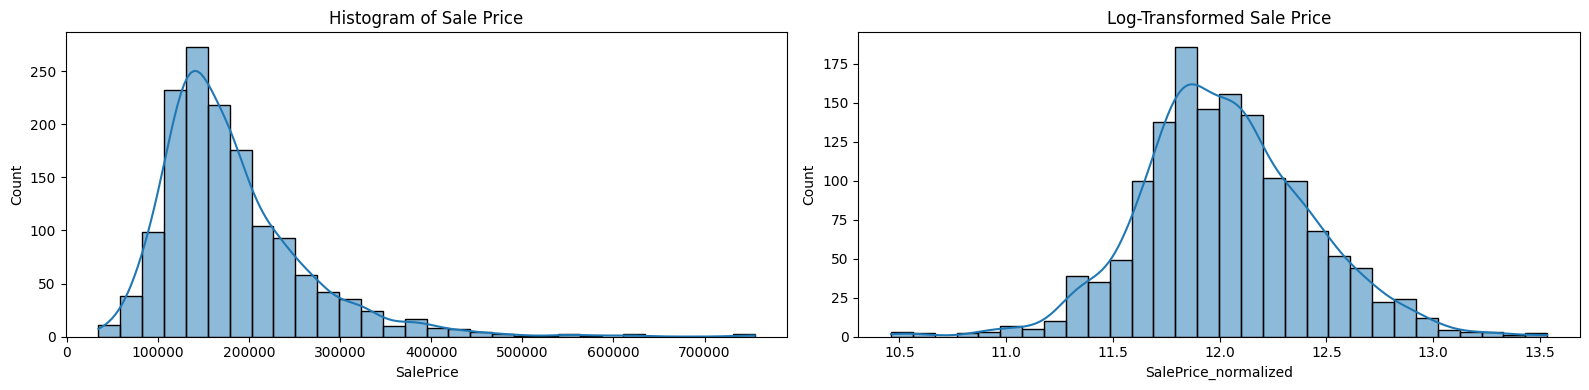

In [2]:
# Log-transform the target for normality
train['SalePrice_normalized'] = np.log1p(train['SalePrice'])

# EDA: Distribution of SalePrice
plt.figure(figsize=(16, 4))
plt.subplot(1, 2, 1)
sns.histplot(train['SalePrice'], bins=30, kde=True)
plt.title('Histogram of Sale Price')

plt.subplot(1, 2, 2)
sns.histplot(train['SalePrice_normalized'], bins=30, kde=True)
plt.title('Log-Transformed Sale Price')
plt.tight_layout()
plt.show()

In [3]:
# Evaluating Skewness and Kurtosis of SalePrice
print("\nSkewness and Kurtosis of SalePrice:")
print("Skewness:", round(train['SalePrice'].skew(), 4))
print("Kurtosis:", round(train['SalePrice'].kurt(), 4))


Skewness and Kurtosis of SalePrice:
Skewness: 1.8829
Kurtosis: 6.5363


The histogram and the skewness/kurtosis measures confirm that `SalePrice` is strongly skewed to the right, i.e., most house prices are clustered at the lower end, with a long tail of higher prices. Additionally, the kurtosis of 6.5363 suggests that house prices  distribution has heavier tails and a sharper peak than a normal distribution, which means that we should expect more frequent and more extreme outliers. Considering the abnormal shape, we will normalize the distribution and explore its relationship to the other features.

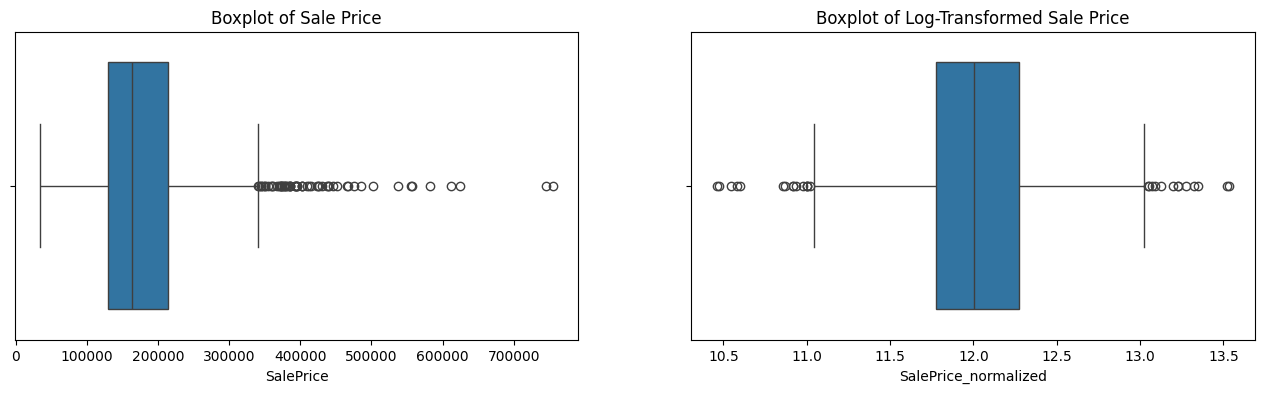

In [4]:
# Generating a Boxplot to visualize SalePrice values above and below interquartile ranges
plt.figure(figsize=(16, 4))
plt.subplot(1, 2, 1)
sns.boxplot(x=train['SalePrice'])
plt.title('Boxplot of Sale Price')

plt.subplot(1, 2, 2)
sns.boxplot(x=train['SalePrice_normalized'])
plt.title('Boxplot of Log-Transformed Sale Price')
plt.show()

# Create new features
train['TotalSF'] = train['TotalBsmtSF'] + train['GrLivArea']
test['TotalSF'] = test['TotalBsmtSF'] + test['GrLivArea']

Observing the boxplot, we note that the `SalePrice` has several outliers (i.e., home prices over $500K). Though low in number, these outliers can inadvertently throw off any linear relationships we may explore.

In [5]:
# Evaluating Skewness and Kurtosis of SalePrice_normalized
print("\nSkewness and Kurtosis of normalized SalePrice:")
print("Skewness:", round(train['SalePrice_normalized'].skew(), 4))
print("Kurtosis:", round(train['SalePrice_normalized'].kurt(), 4))


Skewness and Kurtosis of normalized SalePrice:
Skewness: 0.1213
Kurtosis: 0.8095


The normalized SalePrice distribution is nearly symmetric, with a skew close to zero. The distribution has an excess kurtosis less than three, indicating only a mild presence of outliers/heavier tails. Overall, the distribution is close to normal.

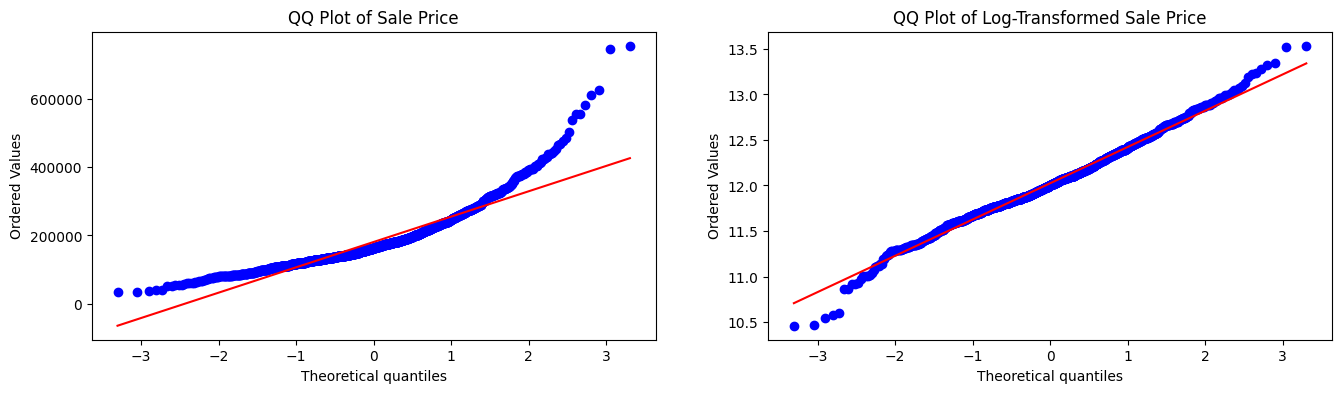

In [6]:
# QQ plot for SalePrice
plt.figure(figsize=(16, 4))
plt.subplot(1, 2, 1)
stats.probplot(train['SalePrice'], dist="norm", plot=plt)
plt.title('QQ Plot of Sale Price')

# QQ plot for SalePrice_normalized
plt.subplot(1, 2, 2)
stats.probplot(train['SalePrice_normalized'], dist="norm", plot=plt)
plt.title('QQ Plot of Log-Transformed Sale Price')
plt.show()

QQ plots compare a given distribution to a theoretical normal distribution. Here, we see that `SalePrice` has heavy-tails and several outliers as confirmed by histogram and boxplots. The points deviate significantly from the red line, especially at the ends (tails). On the right, we note that the log-transformed `SalePrice_normalized` is much more tightly bound around the red-line (i.e. normal distribution). 

To conclude, log-transforming the target variable helps us analyze and model it better as most regression models require/assume normality.

#### 2.1 EVALUATING THE OTHER FEATURES IN THE TRAINING DATASET

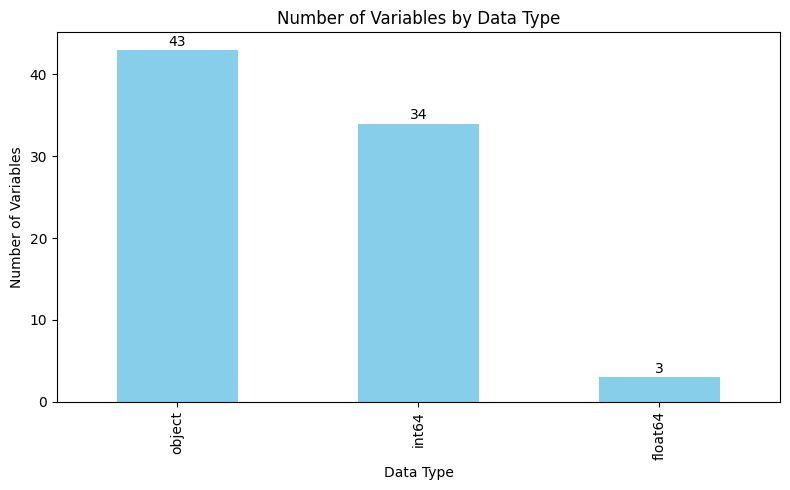

In [7]:
other_features = train.drop(columns=['SalePrice', 'SalePrice_normalized', 'Id'])
data_types = other_features.dtypes.value_counts()

# Plotting the data types of the variables
plt.figure(figsize=(8, 5))
ax = data_types.plot(kind='bar', color='skyblue')

# Adding data labels for clarity
for i, v in enumerate(data_types.values):
    ax.text(i, v + 0.5, str(v), color='black', ha='center')

plt.ylabel('Number of Variables')
plt.xlabel('Data Type')
plt.title('Number of Variables by Data Type')
plt.tight_layout()
plt.show()

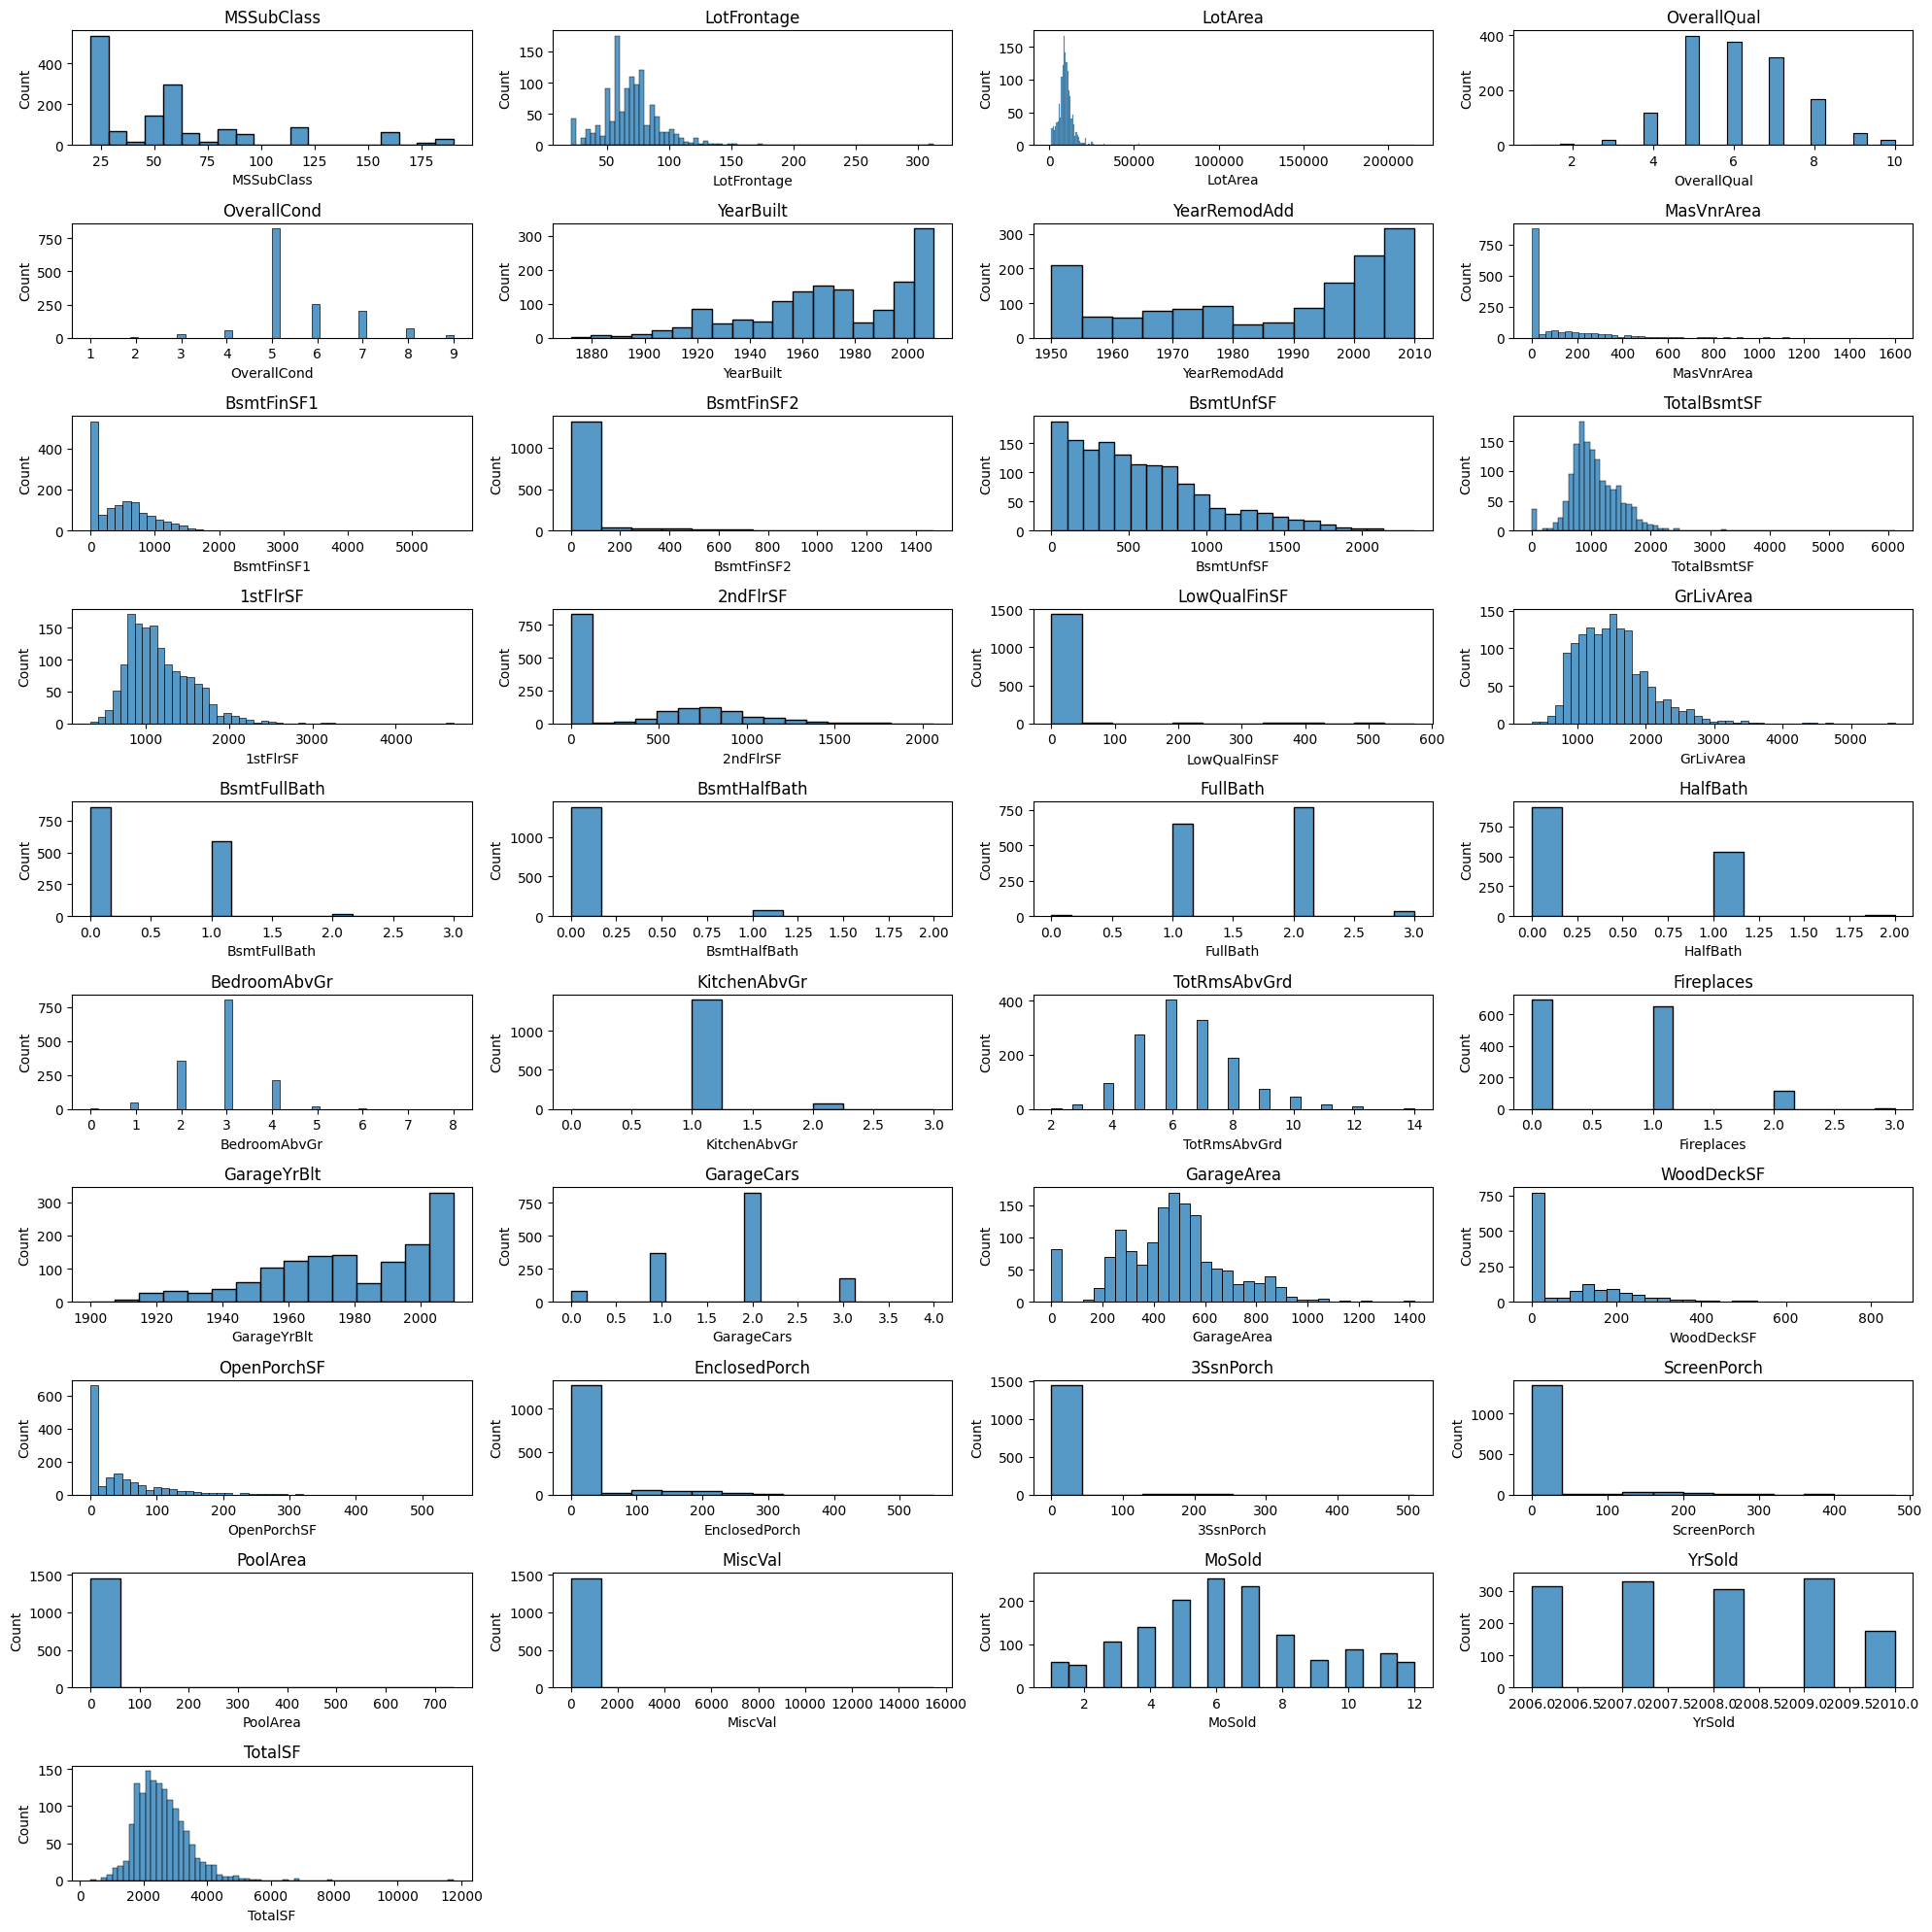

In [8]:
other_features_numeric = other_features.select_dtypes(include=[np.number])

# Box plots for numeric features, 4 per row
num_features = other_features_numeric.columns
n_features = len(num_features)
n_cols = 4
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 2 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(num_features):
    sns.histplot(x=other_features_numeric[feature], ax=axes[i])
    axes[i].set_title(feature)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

We generated and evaluated these histograms to give readers an understanding of the numeric features' distributions. While many of the features (like `GrLivArea`, `1stFlrSF`, and `LotArea`) are right-skewed, we elected not to transform/normalize/scale them as they are common real-estate features.

Additionally:

1. *Interpretability*: We can interpret the impact of features, like square footage and lot area, on the model when they are untransformed.

2. *Model flexibility*: To handle non-linear effects, we will transform the features using polynomial and interaction terms.

3. *Outlier validity*: We believe that outliers (e.g., lots over 200k sqft) represent valid market segments and their retention will better inform stakeholders. 

4. *Target transformation*: We transformed `SalePrice` to stabilized its relationship with other features and further transformation might be redundant.

### 3. FEATURE ENGINEERING


Since we have certain variables that seem related to each other, we will create new features by combining them. 

1. First, we will create `TotalSF` by adding `TotalBsmtSF` & `GrLivArea` to represent total living space of a house.
2. Second, we will create `TotalBathrooms` by combining all full and half bathrooms (with half baths weighted as 0.5), to represent the total number of bathrooms in a house.

In [9]:
# Create new variables to represent TotalBathrooms and TotalSF house has a fireplace
train['TotalBathrooms'] = (
        train['FullBath'] + (0.5 * train['HalfBath']) +
        train['BsmtFullBath'] + (0.5 * train['BsmtHalfBath'])
    )
test['TotalBathrooms'] = (
        test['FullBath'] + (0.5 * test['HalfBath']) +
        test['BsmtFullBath'] + (0.5 * test['BsmtHalfBath'])
    )

train['TotalSF'] = train['TotalBsmtSF'] + train['GrLivArea']
test['TotalSF'] = test['TotalBsmtSF'] + test['GrLivArea']

#### 3.1 INDICATOR, DICHOTOMOUS, AND PIECEWISE VARIABLES

Since Ames, Iowa, experiences heavy snowfall, we assume that fireplaces offer some, if not substantial, value. We will create an indicator variable, `HasFireplace`, to evaluate this.

In [10]:
# Add indicator (dummy) variable for whether house has a fireplace
train['HasFireplace'] = (train['Fireplaces'] > 0).astype(int)
test['HasFireplace'] = (test['Fireplaces'] > 0).astype(int)

Based on our general understanding, modern homes are valued higher than older ones. We will create a feature, `IsModernHome`, to evaluate the house's modernness.

In [11]:
# Variable to identify if house was built after 1980
train['IsModernHome'] = (train['YearBuilt'] >= 1980).astype(int)
test['IsModernHome'] = (test['YearBuilt'] >= 1980).astype(int)

Based on our general understanding, homes under 2,000 sqft gain value with each added square foot, but after 2,000, the gain may flatten out. We will create a piece-wise feature, `TotalSF_2000`, to evaluate the house's modernness.

In [12]:
# Variable to identify if total square footage is over 2,000 sqft
train['TotalSF_over_2000'] = np.maximum(train['TotalSF'] - 2000, 0)
test['TotalSF_over_2000'] = np.maximum(test['TotalSF'] - 2000, 0)

### 4. DATA PREPROCESSING AND FEATURE SELECTION

In [13]:
# Checking for null values in the variables against their data types
nulls_and_types = train.isnull().sum().to_frame('num_nulls')
nulls_and_types['dtype'] = train.dtypes
print(nulls_and_types.sort_values(by = 'num_nulls', ascending=False).head(20))

              num_nulls    dtype
PoolQC             1453   object
MiscFeature        1406   object
Alley              1369   object
Fence              1179   object
MasVnrType          872   object
FireplaceQu         690   object
LotFrontage         259  float64
GarageCond           81   object
GarageType           81   object
GarageFinish         81   object
GarageYrBlt          81  float64
GarageQual           81   object
BsmtFinType2         38   object
BsmtExposure         38   object
BsmtCond             37   object
BsmtFinType1         37   object
BsmtQual             37   object
MasVnrArea            8  float64
Electrical            1   object
MSZoning              0   object


The median is used to fill missing values for features like MasVnrArea, LotFrontage, and GarageYrBlt because it is robust to outliers. Additionally, we believe the median is an appropriate measure to fill the missing values for numeric features as houses will generally be similar to other houses within the city.

In [14]:
# Handle missing values
train = train.fillna(train.median(numeric_only=True))
test = test.fillna(test.median(numeric_only=True))

# Define target
y = train['SalePrice_normalized']

# Train-test split
train_set, val_set = train_test_split(train, test_size=0.2, random_state=42)

# Feature selection: correlation with SalePrice
feature_corr = train_set.corr(numeric_only=True)['SalePrice_normalized'].abs()
top_20_features = feature_corr.drop(['SalePrice', 'SalePrice_normalized']).sort_values(ascending=False).index[:20]

# Extract features
X_train = train_set[top_20_features]
y_train = train_set['SalePrice_normalized']
X_val = val_set[top_20_features]
y_val = val_set['SalePrice_normalized']

# Polynomial features
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_val_poly = poly.transform(X_val)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_val_scaled = scaler.transform(X_val_poly)

*Polynomial Features*
We created a set of polynomial features to allow the regression model to capture non-linear relationships between the predictors and the target variable. Instead of using only the original features, we expand the feature set to include not just each feature itself, but also its squared value and all possible pairwise products (interactions) between features. For example, if the original features are `A` and `B`, the polynomial expansion will include `A`, `B`, `A^2`, `B^2`, and `A*B`. This is accomplished using `PolynomialFeatures(degree=2, include_bias=False)` from scikit-learn, which systematically generates all such terms up to the specified degree (here, degree 2).

*Feature Scaling:*
After polynomial expansion, the resulting feature set can have a wide range of values and scales, especially since squared and interaction terms can be much larger than the original features. Many regression algorithms (including Ridge and Linear Regression) perform better when all features are on a similar scale. To address this, we use `StandardScaler` to standardize each feature so that it has a mean of zero and a standard deviation of one. This ensures that no single feature dominates the model due to its scale, and it helps the optimization process converge more efficiently.

### 5. MODELING

In [15]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_val_scaled)

# Ridge Regression
ridge = Ridge(alpha=10)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_val_scaled)

**Model Criteria in Simple Terms**

*Linear Regression:*  
This model tries to draw the best straight line through the data points so that the differences between the actual house prices and the predicted prices are as small as possible. It does this by minimizing the average of the squared differences (errors) between the real and predicted prices.

*Ridge Regression:*  
Ridge regression does the same as linear regression but adds a rule: it tries to keep the model’s numbers (coefficients) smaller. This extra rule helps prevent the model from getting too “excited” about any one feature, which can make predictions more stable and reliable, especially when features are related to each other. The strength of this rule is controlled by a parameter called alpha (here, set to 10). 

*Why these two models?* <br>
We chose Linear Regression because it is a simple, interpretable baseline that helps us understand the direct relationships between features and house prices. Ridge Regression was selected as a more robust alternative because it can handle situations where features are correlated (multicollinearity). Additionally, it helps prevent overfitting by penalizing large coefficients. Comparing both allows us to see the benefits of regularization and assess whether a more flexible model improves predictive performance.

### 6. MODEL DIAGNOSTICS

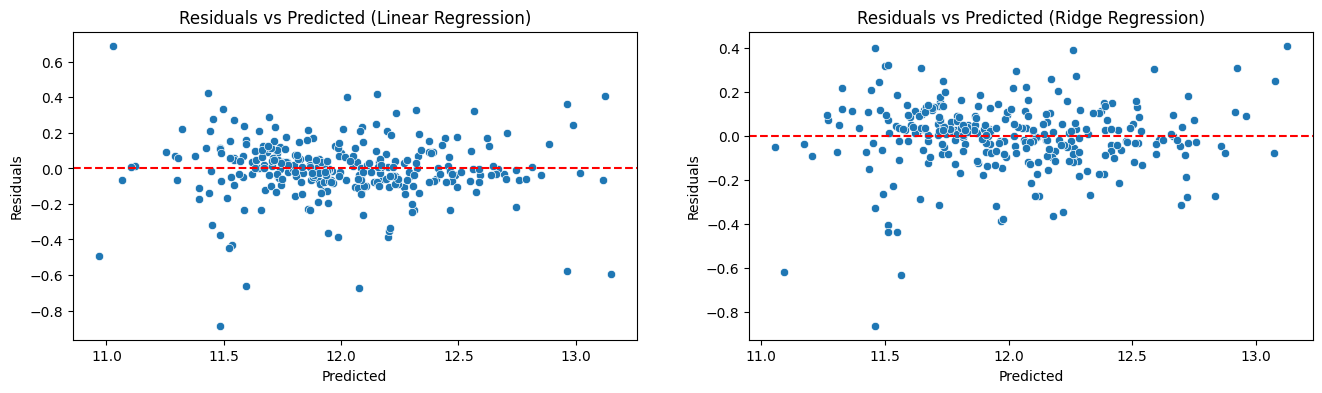

In [16]:
# Linear Regression Residuals Plot
linear_residuals = y_val - y_pred_lr

plt.figure(figsize=(16, 4))
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_pred_lr, y=linear_residuals)
plt.axhline(0, color='r', linestyle='--')
plt.title('Residuals vs Predicted (Linear Regression)')
plt.xlabel('Predicted')
plt.ylabel('Residuals')

# Ridge Regression Residuals Plot
ridge_residuals = y_val - y_pred_ridge
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_pred_ridge, y=ridge_residuals)
plt.axhline(0, color='r', linestyle='--')
plt.title('Residuals vs Predicted (Ridge Regression)')
plt.xlabel('Predicted')
plt.ylabel('Residuals')

plt.show()

The scatterplot of residuals versus predicted values can help us diagnose the performance and assumptions of a regression model. Both models' residuals are randomly scattered around zero suggest that the models errors are linear and vary constantly. The lack of a distinct pattern also suggests that there are no unaccounted variables. 

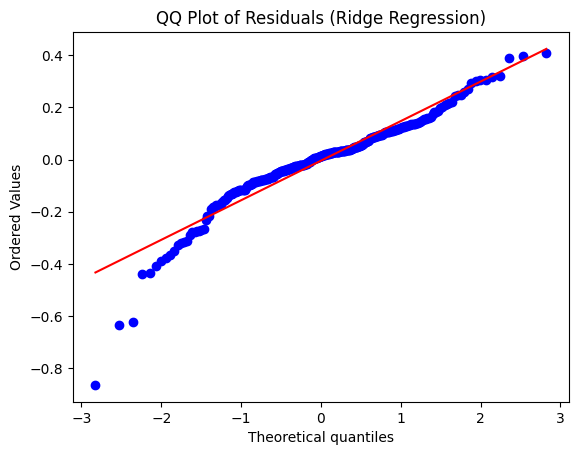

In [17]:
# QQ plot
stats.probplot(ridge_residuals, dist="norm", plot=plt)
plt.title('QQ Plot of Residuals (Ridge Regression)')
plt.show()

Looking at the QQ plot of the residuals, the residuals seem to deviate from a normal distribution, especially at the tails. This may indicate that the model has limitations but deviations are common in real-world data.

Residuals Analysis Summary:
- Residuals range from: $56.86 to $253,135.72
- Quartiles:
    25% of predictions within: $5,246.73
    50% of predictions within: $11,640.47
    75% of predictions within: $24,102.82

21 residuals (7.19%) exceed 2 standard deviations.



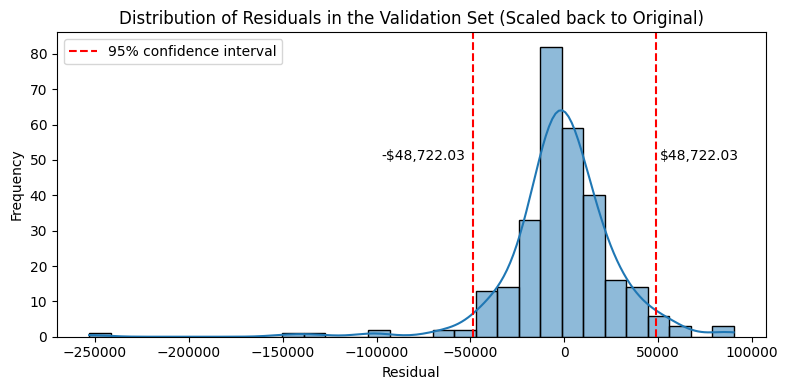

In [18]:
# Converting residuals back to original scale
y_true_orig = np.expm1(y_val)
y_pred_orig = np.expm1(y_pred_ridge)
residuals_orig = y_pred_orig - y_true_orig

# Standard deviation and average of errors
desc = abs(residuals_orig).describe()

summary = (
    f"Residuals Analysis Summary:\n"
    f"- Residuals range from: ${desc['min']:,.2f} to ${desc['max']:,.2f}\n"
    f"- Quartiles:\n"
    f"    25% of predictions within: ${abs(desc['25%']):,.2f}\n"
    f"    50% of predictions within: ${abs(desc['50%']):,.2f}\n"
    f"    75% of predictions within: ${abs(desc['75%']):,.2f}\n"
)
print(summary)

outlier_count = (abs(residuals_orig) > 2 * abs(desc['std'])).sum()
outlier_pct = 100 * outlier_count / desc['count']
print(f"{outlier_count} residuals ({outlier_pct:.2f}%) exceed 2 standard deviations.\n")



# Histogram of residuals
plt.figure(figsize=(8, 4))
sns.histplot(residuals_orig, bins=30, kde=True)
plt.title("Distribution of Residuals in the Validation Set (Scaled back to Original)")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.axvline(2 * desc['std'], color='red', linestyle='--', label = "95% confidence interval")
plt.text(x=2.1 * desc['std'], y = 50, s = f"${2 * desc['std']:,.2f}")
plt.text(x=-4 * desc['std'], y = 50, s = f"-${2 * desc['std']:,.2f}")
plt.axvline(-2 * desc['std'], color='red', linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()

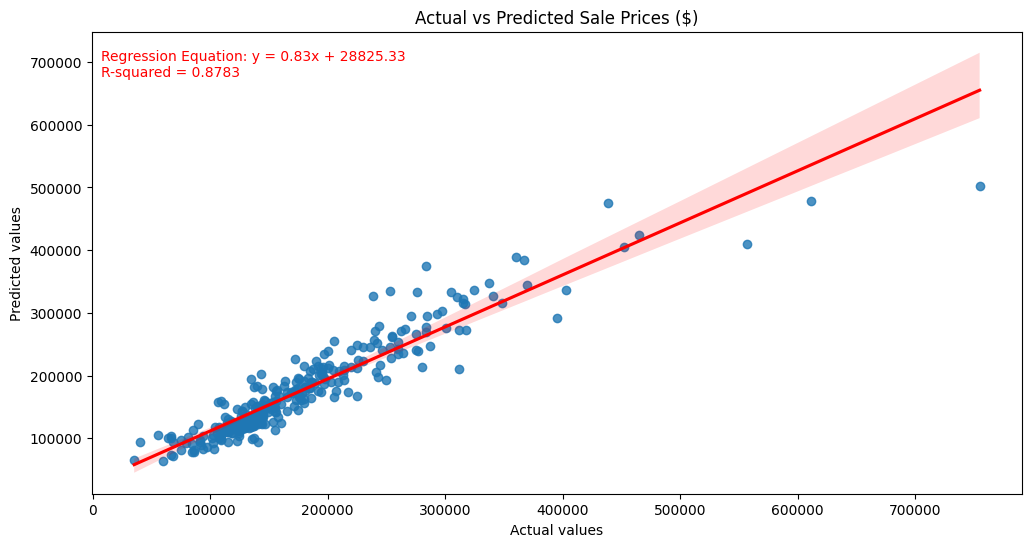

In [19]:
# Calculate regression coefficients
slope, intercept, r_value, p_value, std_err = stats.linregress(y_true_orig, y_pred_orig)
r_squared = r_value**2

# Format equation string
equation = f'y = {slope:.2f}x + {intercept:.2f}\nR-squared = {r_squared:.4f}'

# Scatterplot of actual vs predicted
plt.figure(figsize=(12, 6))
sns.regplot(x=y_true_orig, y=y_pred_orig, line_kws={"color": "red"})
plt.xlabel('Actual values')
plt.ylabel('Predicted values')
plt.title('Actual vs Predicted Sale Prices ($)')

# Add equation text on plot (adjust coordinates as needed)
plt.text(min(y_true_orig) * 0.2, max(y_pred_orig) * 1.35, s = f"Regression Equation: {equation}", color='red')

plt.show()

**Analysis of Residuals and Predictions**

After analyzing the residuals, we observed the following:
1. Precision: On average, predictions are off by <1%, and 95% of errors within the $50,000 range.
2. Outliers: The model performs well for almost all homes, with errors beyond the 95% confidence interval in about 7% of the households.
3. Skew: The residuals distribution is heavily skewed to the left, indicating that the model tends to understate home values.

The model is solid and dependable overall, particularly for most mid- to lower-priced homes.

### 7. CROSS-VALIDATION

To assess if the models' performance is due to a "fluke", we will use cross-validation on the training set with the top 20 features, including the polynomial features. We will also scale the features in our evaluation.

In [20]:
X_full = train[top_20_features]
y_full = train['SalePrice_normalized']
pipeline_lr = make_pipeline(PolynomialFeatures(degree=2, include_bias=False), StandardScaler(), LinearRegression())
pipeline_ridge = make_pipeline(PolynomialFeatures(degree=2, include_bias=False), StandardScaler(), Ridge(alpha=10))

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_lr = cross_val_score(pipeline_lr, X_full, y_full, cv=kf, scoring='r2')
cv_scores_ridge = cross_val_score(pipeline_ridge, X_full, y_full, cv=kf, scoring='r2')

print("Cross-Validated R-squared value (Linear Regression):", round(cv_scores_lr.mean(), 4))
print("Cross-Validated R-squared value (Ridge Regression):", round(cv_scores_ridge.mean(), 4))

Cross-Validated R-squared value (Linear Regression): 0.8318
Cross-Validated R-squared value (Ridge Regression): 0.8594


**Cross-Validation Design** <br>
We used a five-fold cross-validation design to split the training data into five parts, train on four parts, and validate themselves on the fifth — including rotating the models through each part. By evaluating the model's performance across different samples and protects against overfitting. These results show that the Ridge Regression model generalizes much better to unseen data compared to the standard Linear Regression, likely due to its regularization and ability to handle multicollinearity among the polynomial features.

### 8. MODEL EVALUATION

In [21]:
def evaluate_model(name, y_true, y_pred):
    print(f"\n{name} Metrics on Validation Set:\n")
    print("R-squared value:", round(r2_score(y_true, y_pred), 4))
    print("Mean Squared Error:", round(mean_squared_error(y_true, y_pred), 4))
    print("Root Mean Squared Error:", round(np.sqrt(mean_squared_error(y_true, y_pred)), 4))
    print("Mean Absolute Percentage Error (%):", round(mean_absolute_percentage_error(y_true, y_pred) * 100, 2))

evaluate_model("Linear Regression", y_val, y_pred_lr)
evaluate_model("Ridge Regression", y_val, y_pred_ridge)


Linear Regression Metrics on Validation Set:

R-squared value: 0.8409
Mean Squared Error: 0.0297
Root Mean Squared Error: 0.1723
Mean Absolute Percentage Error (%): 0.96

Ridge Regression Metrics on Validation Set:

R-squared value: 0.8682
Mean Squared Error: 0.0246
Root Mean Squared Error: 0.1568
Mean Absolute Percentage Error (%): 0.92


**Interpretation of Key Results**

We evaluated model performance using four different measures: R-squared error (R²), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE).  Across the board, we noted that Ridge Regression performed better than Linear Regression in both cross-validation and train-test split validation sets. Ridge can explain house prices better using the available features, as demonstrated by its higher cross-validated R² score of 0.8594 versus 0.8318 for Linear Regression. Further, Ridge makes smaller prediction errors on average, as shown by its lower MSE, RMSE & MAPE scores than Linear.  To summarize, we note that Ridge is a more accurate model as it can better handle the complex patterns in the data.

In [22]:
# Evaluating variance inflation factor (VIF) to evaluate features for multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_data = pd.DataFrame()
vif_data["Feature"] = X_train.columns
vif_data["VIF"] = [variance_inflation_factor(X_train.values, i) for i in range(len(X_train.columns))]
print("VIF Analysis:")
print(vif_data.assign(VIF=vif_data["VIF"].round(4)).sort_values('VIF', ascending=False))

# Add Durbin-Watson test for independence
from statsmodels.stats.stattools import durbin_watson
dw_stat = durbin_watson(ridge_residuals)
print(f"Durbin-Watson statistic: {dw_stat:.4f}")

# Add Breusch-Pagan test for homoscedasticity
from statsmodels.stats.diagnostic import het_breuschpagan

# Add constant to exog for Breusch-Pagan test
import statsmodels.api as sm
exog_with_const = sm.add_constant(X_val_scaled)
bp_stat, bp_pvalue, _, _ = het_breuschpagan(ridge_residuals, exog_with_const)
print(f"Breusch-Pagan test p-value: {bp_pvalue:.4f}")

VIF Analysis:
              Feature         VIF
1             TotalSF         inf
3           GrLivArea         inf
7         TotalBsmtSF         inf
16        GarageYrBlt  18831.6642
11          YearBuilt  15166.0058
12       YearRemodAdd  13192.0411
0         OverallQual     62.7240
13       TotRmsAbvGrd     61.9240
2   TotalSF_over_2000     46.6286
10           1stFlrSF     44.1654
4          GarageCars     37.7514
5      TotalBathrooms     33.5039
6          GarageArea     32.4409
9            FullBath     29.9394
14       HasFireplace     12.6688
15         Fireplaces     11.8101
8        IsModernHome      4.6776
18         BsmtFinSF1      4.5504
17         MasVnrArea      1.9154
19         WoodDeckSF      1.7915
Durbin-Watson statistic: 2.0045
Breusch-Pagan test p-value: 0.3422


There are some features with infinite collinearity as they are mathematical operations of each other. However, using Ridge regression solves this for us by penalizing large coefficients.

In [23]:
# Calculating coefficient shrinkage caused by Ridge Regression
max_lr_coef = round(np.max(np.abs(lr.coef_)), 4)
max_ridge_coef = round(np.max(np.abs(ridge.coef_)), 4)

print(f"\nRidge shrinkage effect (alpha={10}):")
print(f"Linear regression max coefficient: {max_lr_coef}")
print(f"Ridge regression max coefficient: {max_ridge_coef}")
print(f"Shrinkage ratio: {round((max_lr_coef - max_ridge_coef) * 100 / max_lr_coef, 2)}%")


Ridge shrinkage effect (alpha=10):
Linear regression max coefficient: 6.4691
Ridge regression max coefficient: 0.0505
Shrinkage ratio: 99.22%


#### 8.1 MODEL ASSUMPTIONS

When building our regression models, we assumed the following:

1. *Linearity*: We assume that the features in the data have linear relationships with the target, `SalePrice`. We confirmed this by performing a correlation analysis to the target variable. Where we could not detect linear relationships, we (a) created polynomial terms (e.g., GrLivArea², GarageCars * TotalSF) to transform these features for our evaluation & (b) added piecewise components like TotalSF_over_2000 to model diminishing returns for large homes.

2. *Independence of Errors*: We assume that modeling errors will be unrelated to each other. We confirmed this by plotting residuals for both models and confirmed that they showed no clear trends. Further, the Durbin-Watson statistic of 2.0322 shows that the data is very close to the ideal value of 2, indicating that the errors/residuals are unrelated.

3. *Normality of Errors*: We assume that the errors will be normally distributed. We visualized them in a QQ plot and confirmed that they mostly follow a straight line. Further, our previous normalization of `SalePrice` would have a knock-on effect on the model's residuals.

4. *Homoskedacity (Constant Error Variance)*: We assume that errors will be equally spread. We confirmed this residuals by visualizing the errors in a QQ plot and evaluating it for funneling or spreading patterns . Further, we evaluated the residuals using a Breusch-Pagan test that showed a p-value higher than 0.05, rejecting the null hypothesis of equal variance and supporting our assumption of homoskedasticity in our model.

5. *Multicollinearity*: We assume that the features will be related to each other as houses are generally built using set proportions between these features. Further, excluding features correlating with each other might remove important relationships. By using Ridge Regression, we penalize these relationships with large coefficients and shrink them to prevent overfitting.

6. *Feature Relevance*: Since we lack domain expertise, we assume that all the top features selected are relevant for real-estate modeling.

#### 8.2 FEATURE IMPORTANCE (Ridge Regression)

We looked at the top features used in the better performing model, i.e. the Ridge model, used in predicting house prices. As we used polynomial features (i.e., features created by combining with multiple features), we get the actual feature names generated during polynomial transformation and then derive only the absolute values from the coefficients.

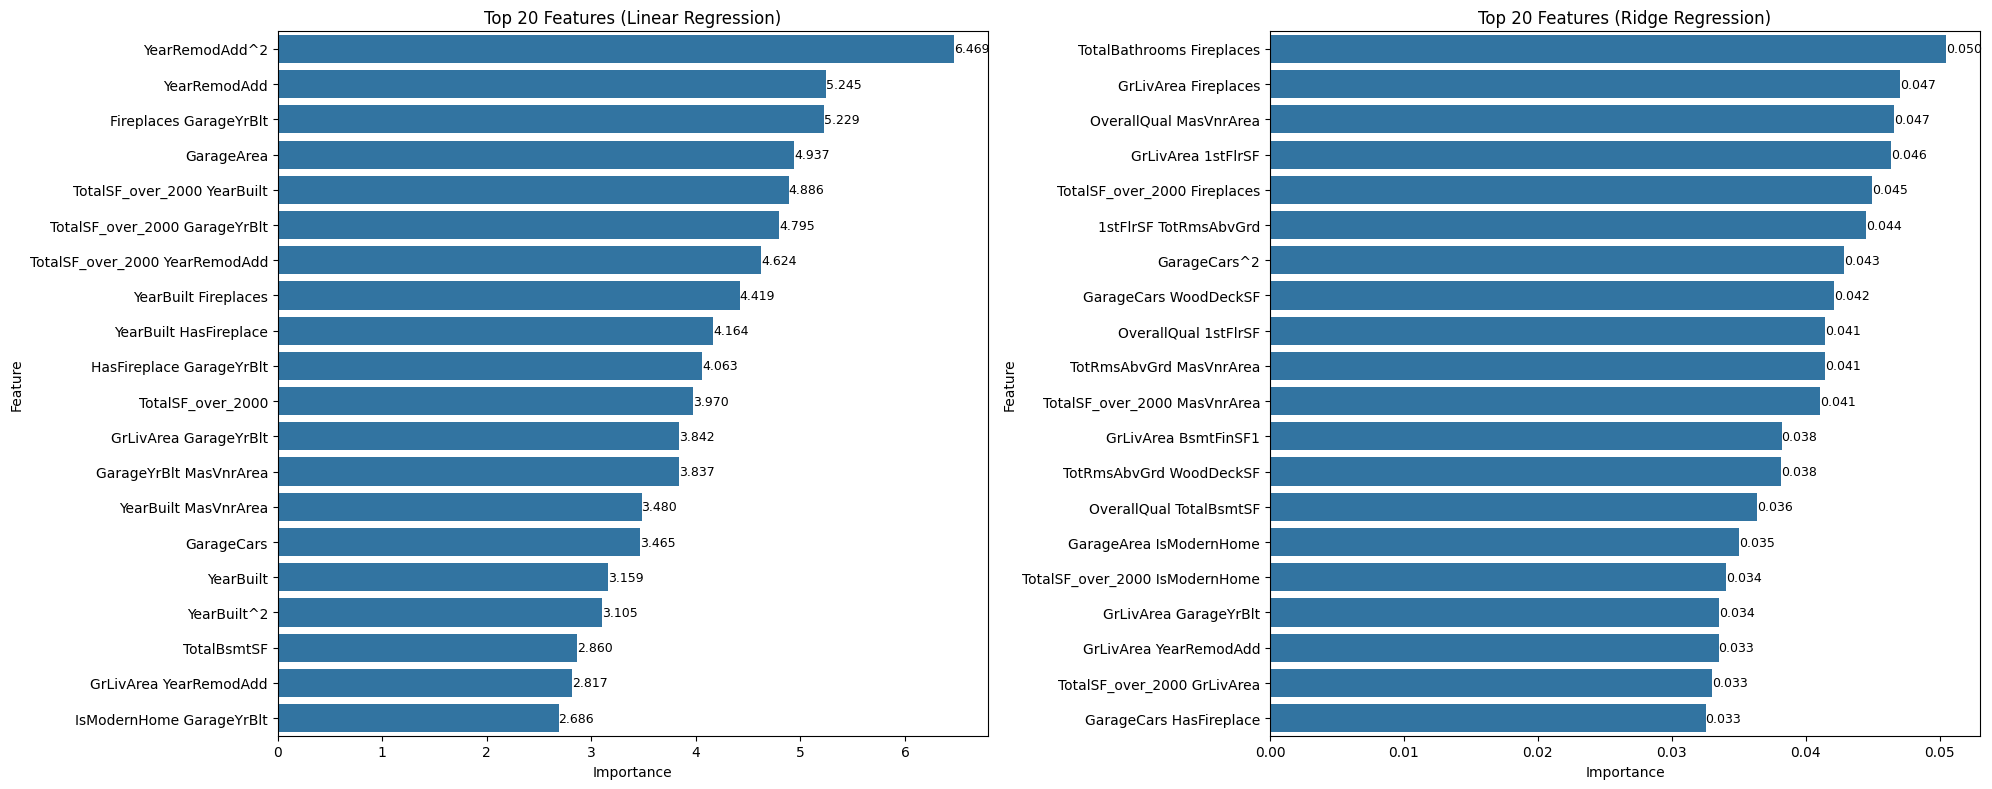

In [24]:
# Get feature names after polynomial transformation
poly_feature_names = poly.get_feature_names_out(top_20_features)

# Get absolute values of Linear Regression coefficients
lr_importance = np.abs(lr.coef_)

# Create a DataFrame of feature importances
lr_importance_df = pd.DataFrame({'Feature': poly_feature_names, 'Importance': lr_importance})

# Sort by importance
lr_importance_df = lr_importance_df.sort_values(by='Importance', ascending=False)

# Get absolute values of Ridge coefficients
ridge_importance = np.abs(ridge.coef_)

# Create a DataFrame of feature importances
ridge_importance_df = pd.DataFrame({'Feature': poly_feature_names, 'Importance': ridge_importance})

# Sort by importance
ridge_importance_df = ridge_importance_df.sort_values(by='Importance', ascending=False)

# Plot top 20 most important features
plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
ax = sns.barplot(x='Importance', y='Feature', data=lr_importance_df.head(20))
plt.title('Top 20 Features (Linear Regression)')
plt.tight_layout()

# Add data labels
for i, (importance, feature) in enumerate(zip(lr_importance_df.head(20)['Importance'], lr_importance_df.head(20)['Feature'])):
    ax.text(importance, i, f"{importance:.3f}", va='center', ha='left', fontsize=9, color='black')

# Plot top 20 most important features
plt.subplot(1, 2, 2)
ax = sns.barplot(x='Importance', y='Feature', data=ridge_importance_df.head(20))
plt.title('Top 20 Features (Ridge Regression)')
plt.tight_layout()

# Add data labels
for i, (importance, feature) in enumerate(zip(ridge_importance_df.head(20)['Importance'], ridge_importance_df.head(20)['Feature'])):
    ax.text(importance, i, f"{importance:.3f}", va='center', ha='left', fontsize=9, color='black')

plt.show()

The feature important charts above show us that the linear model identifies just a few features as highly important, whereas the Ridge model distributes influence across a broader set of features. Our general understanding of real-estate dynamics suggest that the features selected by the Ridge model reflect a more comprehensive approach to pricing

### 9. FINAL PREDICTIONS

In [25]:
X_test = test[top_20_features]
X_test_poly = poly.transform(X_test)
X_test_scaled = scaler.transform(X_test_poly)
y_test_pred_normalized = ridge.predict(X_test_scaled)
y_test_pred = np.expm1(y_test_pred_normalized)

submission = pd.DataFrame({
    "Id": test["Id"],
    "SalePrice": y_test_pred
})

submission.to_clipboard(index=False)

submission.to_csv("ridge_submission.csv", index=False)
print("Test predictions saved to ridge_submission.csv")

Test predictions saved to ridge_submission.csv


In [26]:
pd.DataFrame(X_val).to_clipboard()

#### 9.1 DISCUSSION OF MODEL IN LAYMAN'S TERMS

Our model looks at many features (inherent and engineered) to predict a house's sale price, such as the number of bathrooms, living space, garage size, and whether it has a fireplace.

In the feature importance chart above, we showed how much impact a specific feature had on the predicted price. 

**Key takeaways:**<br>
1. Bathrooms + Fireplaces: Houses with more bathrooms and fireplaces tend to sell for more. These two together were the strongest signal for price.

2. Overall Quality + Masonry Veneer Area: Higher-rated homes and those with quality exterior materials like brick or stone contribute significantly to value.

3. Living Area (GrLivArea): The more usable above-ground space a house has, the more it tends to be worth. However, this effect can change depending on other features.

4. Garage Features: Not only does the number of garage spaces matter, but even how they interact with other features (like wood decks or fireplaces) matters too.

5. Modern Homes (Built After 1980): These seem to fetch higher prices, possibly because they have newer construction, updated layouts, or modern amenities.

6. Piecewise Effects (like TotalSF_over_2000): The model learns that houses larger than 2000 sq ft don't always increase in value at the same rate — buyers may not pay as much extra per square foot once the house is already large.

**Why is this important?** <br>
This means if you’re trying to understand what drives house prices:

1. Size and quality matter, but not in isolation — it’s about how features interact.

2. Modern features and efficient layouts can boost value more than sheer size alone.

3. Extra features (like fireplaces, garages, and bathrooms) help a lot — especially in combination.

This Ridge model, enhanced with polynomial and interaction terms, captures complex patterns in the housing market that a basic model would miss. And because it uses cross-validation, we’re confident that its predictions are reliable and not just lucky guesses on one dataset.

<p style="page-break-after:always;"></p>

# Appendix 2: Kaggle Profile and Submissions

<i> Uploader's Kaggle profile: https://www.kaggle.com/shishirdeshpandenwu </i>
<br>
<img src="Kaggle_Profile.png" height = 300>

<i> Using cross-validated, Ridge Regression Model with engineered and polynomial features </i> <br>
<img src="Ridge Regression.png" height = 400 >